# Exploratory Data Analysis (EDA)

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Load the ML Dataset

In [72]:
# Load the Barcelona noise ML dataset
dataset = pd.read_csv("../../data/machine_learning/bcn_noise_ml_dataset_halved.csv")

print(f"Dataset shape: {dataset.shape}")
dataset.head()
print(dataset.columns.tolist())

Dataset shape: (8386, 66)
['street_id', 'noise_day', 'noise_evening', 'noise_night', 'road_length', 'road_category', 'one_way', 'distance_to_road', 'fid', 'osm_commercial_pct_50m', 'osm_green_pct_50m', 'osm_industrial_pct_50m', 'osm_other_pct_50m', 'osm_residential_pct_50m', 'slope_pct', 'catastral_bldg_floors_mean_50m', 'catastral_bldg_floors_max_50m', 'catastral_bldg_floors_mean_100m', 'catastral_bldg_floors_max_100m', 'signal_count_50', 'poi_count_50', 'tree_count_50', 'transport_count_50', 'TRAM', 'street_length_m', 'daytime_count_100m', 'nighttime_count_100m', 'continuous_count_100m', 'discontinuous_count_100m', 'transport_related_count_100m', 'noise_sensitive_count_100m', 'recreation_green_count_100m', 'support_infrastructure_count_100m', 'daytime_count_per_meter_100m', 'nighttime_count_per_meter_100m', 'continuous_count_per_meter_100m', 'discontinuous_count_per_meter_100m', 'transport_related_count_per_meter_100m', 'noise_sensitive_count_per_meter_100m', 'recreation_green_count_

## Reduce the number of columns

In [6]:
columns = ['noise_day','noise_evening','noise_night', 'road_category', 'road_width', 'openness', 'road_length','osm_commercial_pct_50m', 'osm_green_pct_50m', 'osm_industrial_pct_50m', 'osm_other_pct_50m', 'osm_residential_pct_50m', 'slope_pct', 'catastral_bldg_floors_mean_50m', 'signal_count_50', 'poi_count_50', 'tree_count_50', 'transport_count_50', 'edge_betweenness']
dataset_small = dataset[columns]
print(dataset_small.columns.tolist())

['noise_day', 'noise_evening', 'noise_night', 'road_category', 'road_width', 'openness', 'road_length', 'osm_commercial_pct_50m', 'osm_green_pct_50m', 'osm_industrial_pct_50m', 'osm_other_pct_50m', 'osm_residential_pct_50m', 'slope_pct', 'catastral_bldg_floors_mean_50m', 'signal_count_50', 'poi_count_50', 'tree_count_50', 'transport_count_50', 'edge_betweenness']


<Axes: >

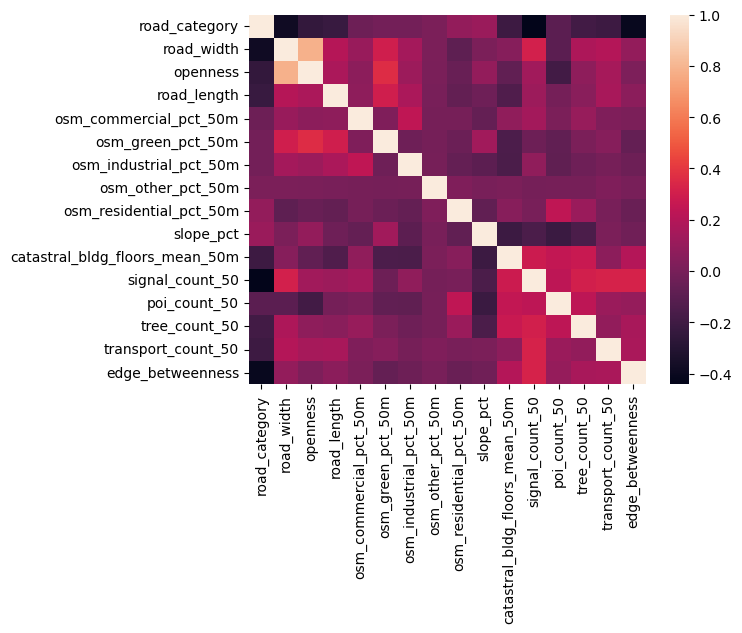

In [7]:
dataset_num = dataset_small.drop(columns=['noise_day', 'noise_evening', 'noise_night']) #dropping y and non-numeric columns
sns.heatmap(dataset_num.corr())

## Calculate Spearman correlation

Pearson measures linear relationships
-> very sensitive to outliers and nonlinear patterns

Spearman measures rank-order relationships
-> works well with nonlinear relationships and is more robust to outliers 

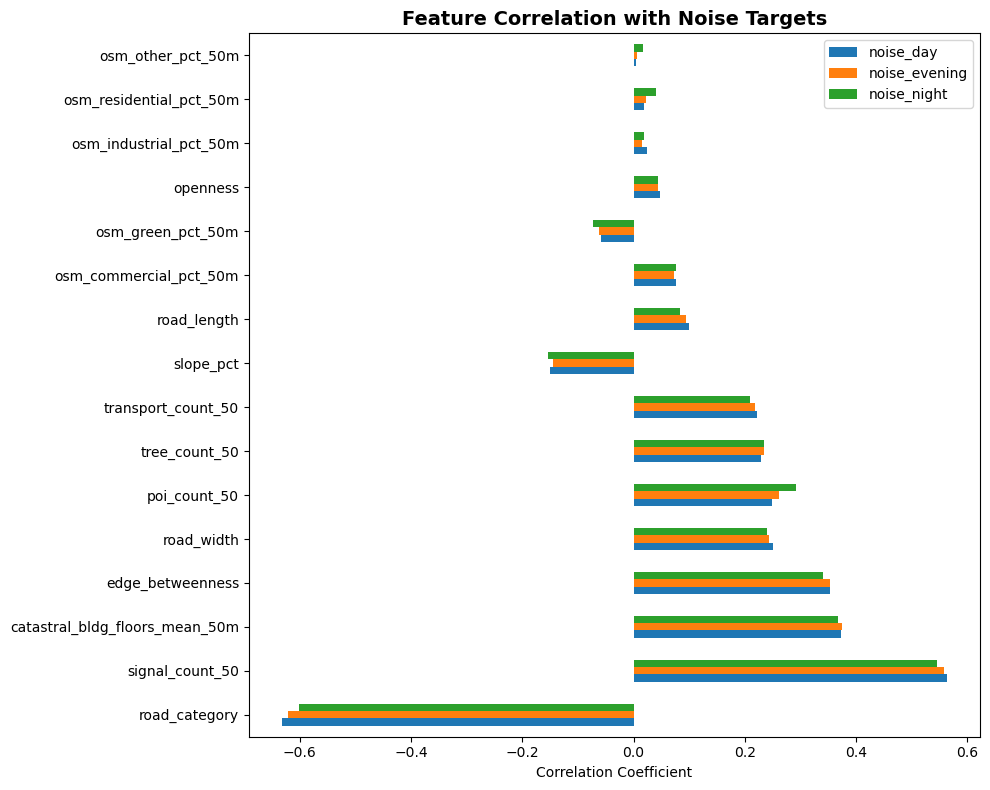

                                noise_day  noise_evening  noise_night
signal_count_50                  0.563049       0.557488     0.545095
catastral_bldg_floors_mean_50m   0.373184       0.374266     0.367058
edge_betweenness                 0.353645       0.353185     0.339917
road_width                       0.251046       0.243865     0.239440
poi_count_50                     0.249438       0.261028     0.291987
tree_count_50                    0.229094       0.234321     0.234143
transport_count_50               0.222093       0.218731     0.208601
road_length                      0.099990       0.094215     0.083960
osm_commercial_pct_50m           0.076721       0.073068     0.076501
openness                         0.048143       0.043031     0.044157
osm_industrial_pct_50m           0.023468       0.014782     0.019106
osm_residential_pct_50m          0.018147       0.023123     0.039531
osm_other_pct_50m                0.003525       0.007057     0.016249
osm_green_pct_50m   

In [15]:
# Extract correlations with noise predictions
target_cols = ['noise_day', 'noise_evening', 'noise_night']
feature_correlation = dataset_small.corr(method = 'spearman')[target_cols].drop(target_cols)

# Sort by absolute correlation
feature_correlation_sorted = feature_correlation.abs().sort_values('noise_day', ascending=False)

# Plot bar chart
fig, ax = plt.subplots(figsize=(10, 8))
feature_correlation.loc[feature_correlation_sorted.index].plot(kind='barh', ax=ax)
ax.set_title('Feature Correlation with Noise Targets', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print(feature_correlation.sort_values('noise_day', ascending=False))

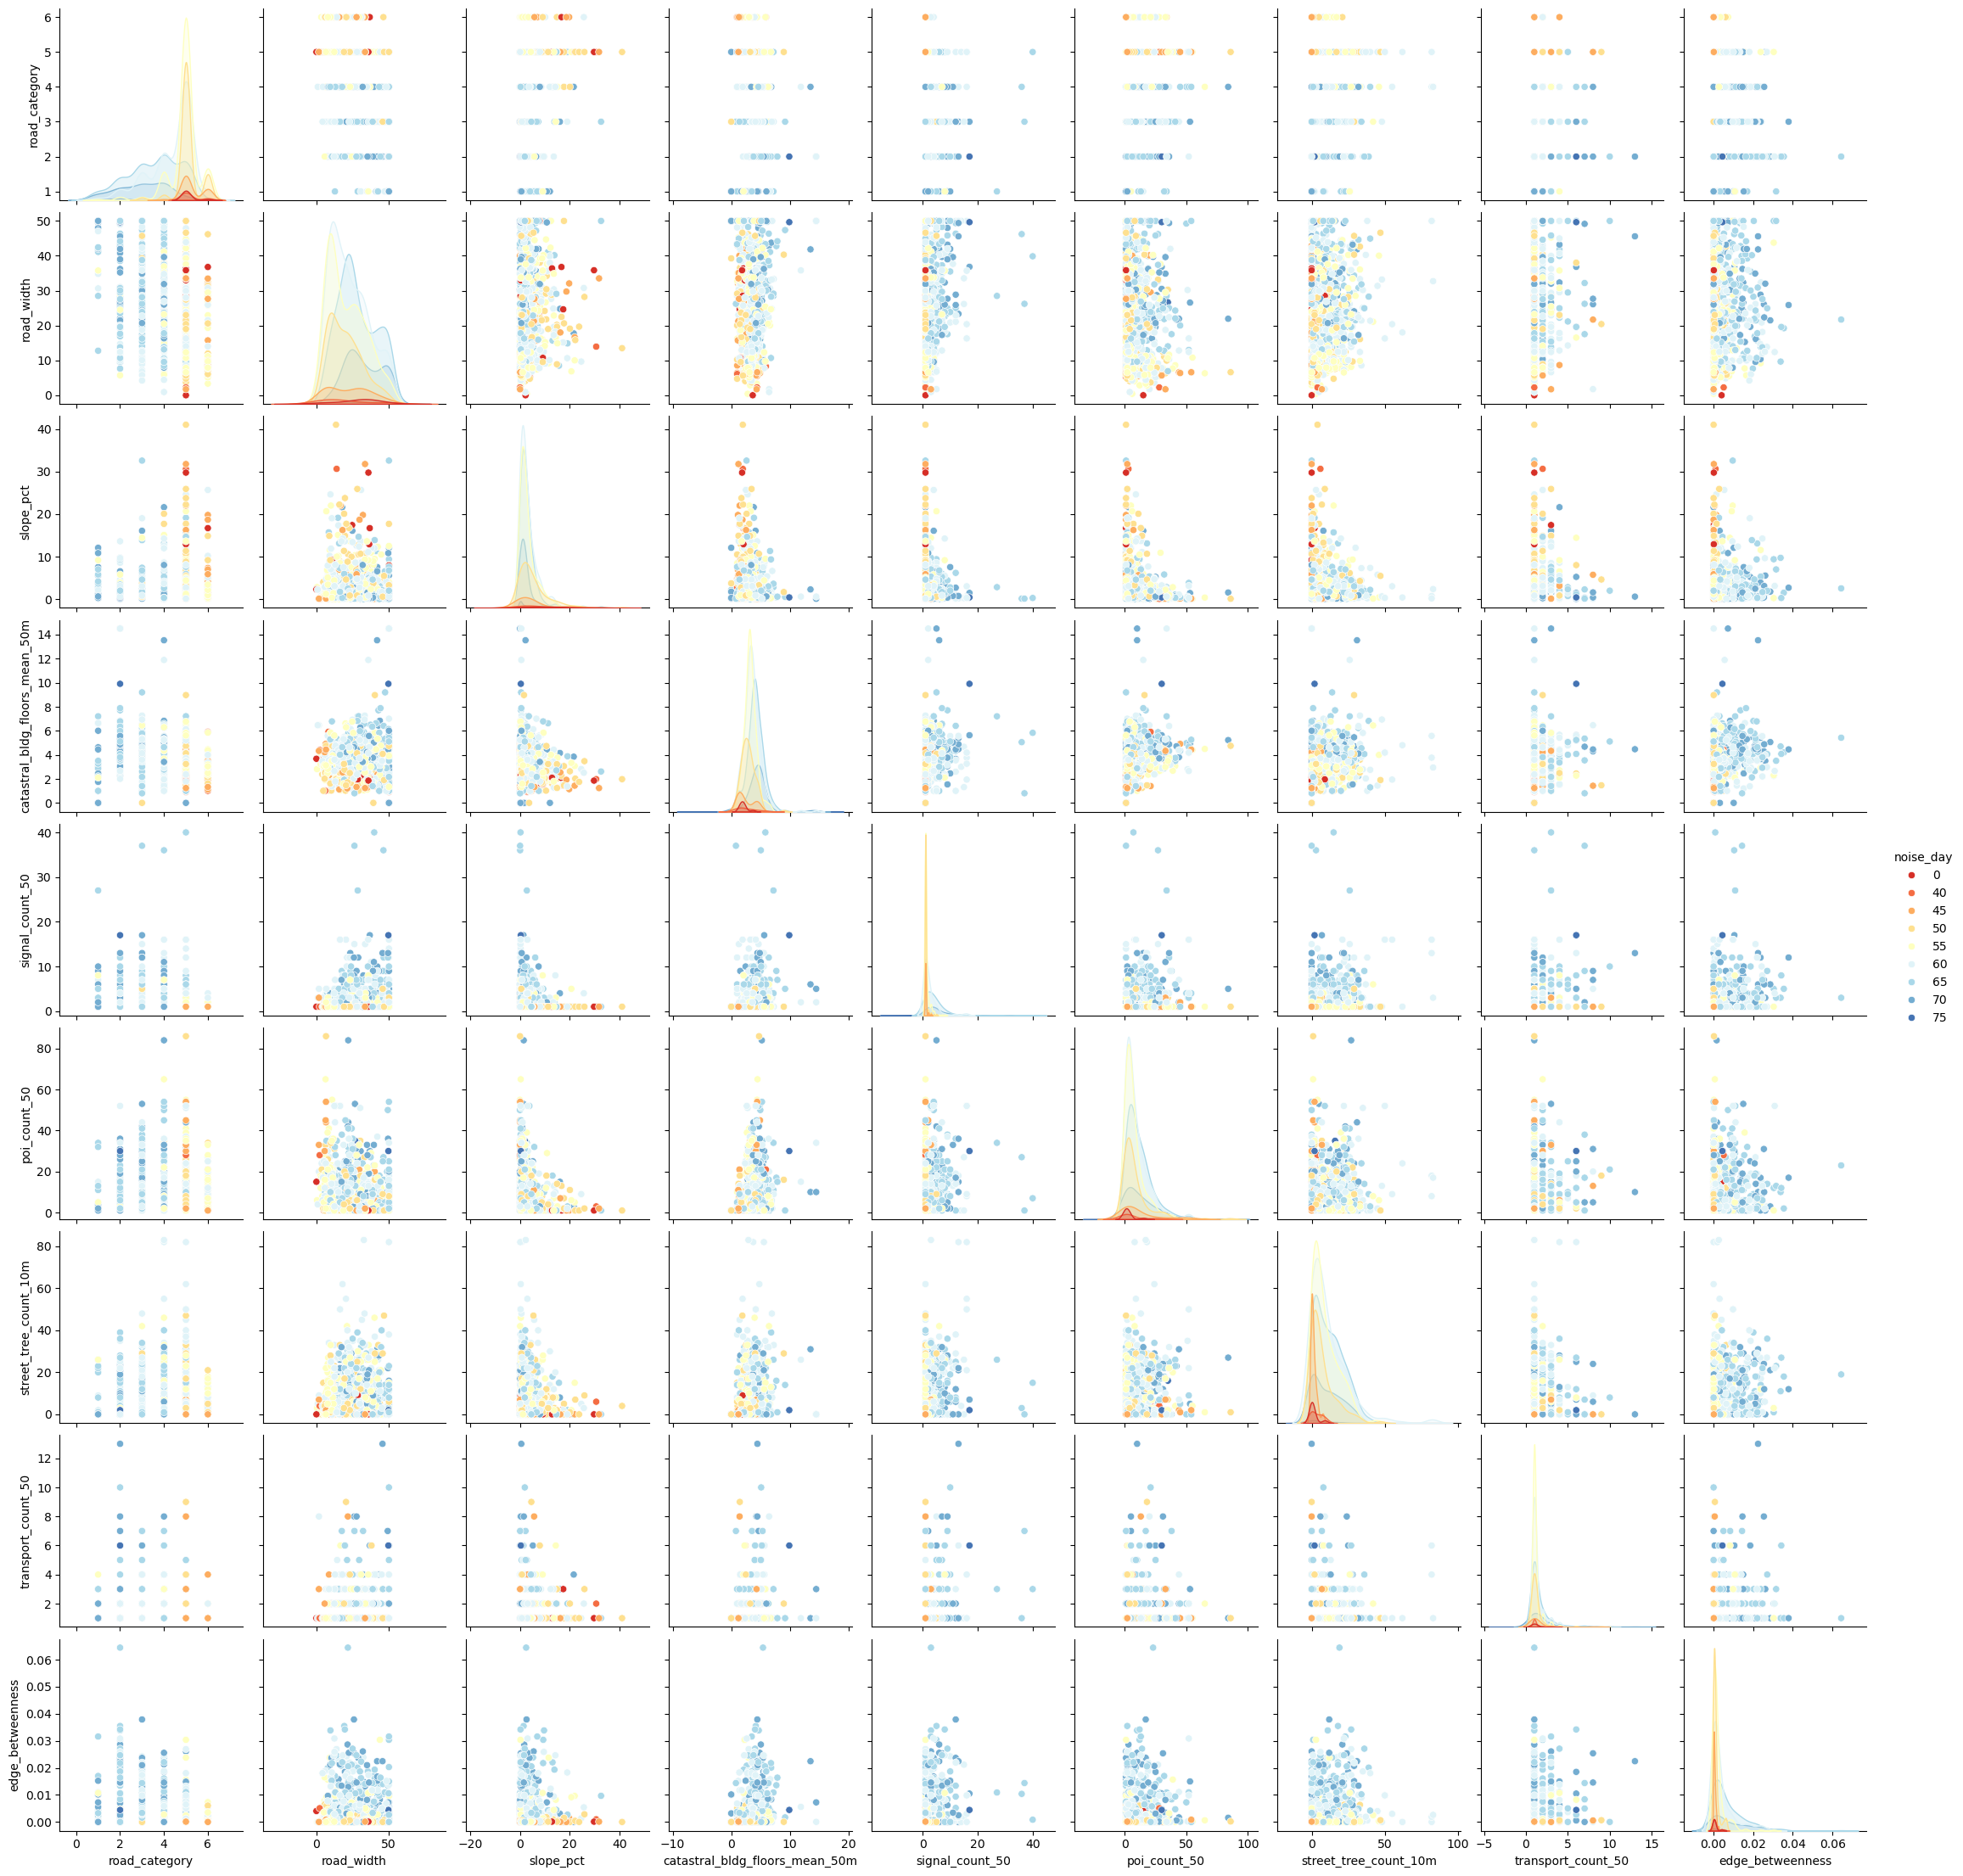

In [30]:
dataset_extra_small = dataset[['noise_day','road_category', 'road_width', 'slope_pct', 'catastral_bldg_floors_mean_50m', 'signal_count_50', 'poi_count_50', 'street_tree_count_10m', 'transport_count_50','edge_betweenness']]

# Sample randomly
sample = dataset_extra_small.sample(n=1000, random_state=42).copy()

# Get unique noise_day values sorted and convert to ordered categorical
sorted_noise_values = sorted(sample['noise_day'].unique())
sample['noise_day'] = pd.Categorical(sample['noise_day'], categories=sorted_noise_values, ordered=True)

sns.pairplot(sample, hue="noise_day", palette="RdYlBu", corner=False)

In [24]:
print("Noise Day values:")
print(dataset['noise_day'].unique())
print("\nUnique values count:", dataset['noise_day'].nunique())


Noise Day values:
[55 50 45 60 65 70 40  0 75]

Unique values count: 9


## Noise Distribution by Road Category

[55 50 45 60 65 70 40 35 75]
[55 50 45 60 65 70 40 35]
[50 45 40 55 60 65 35]


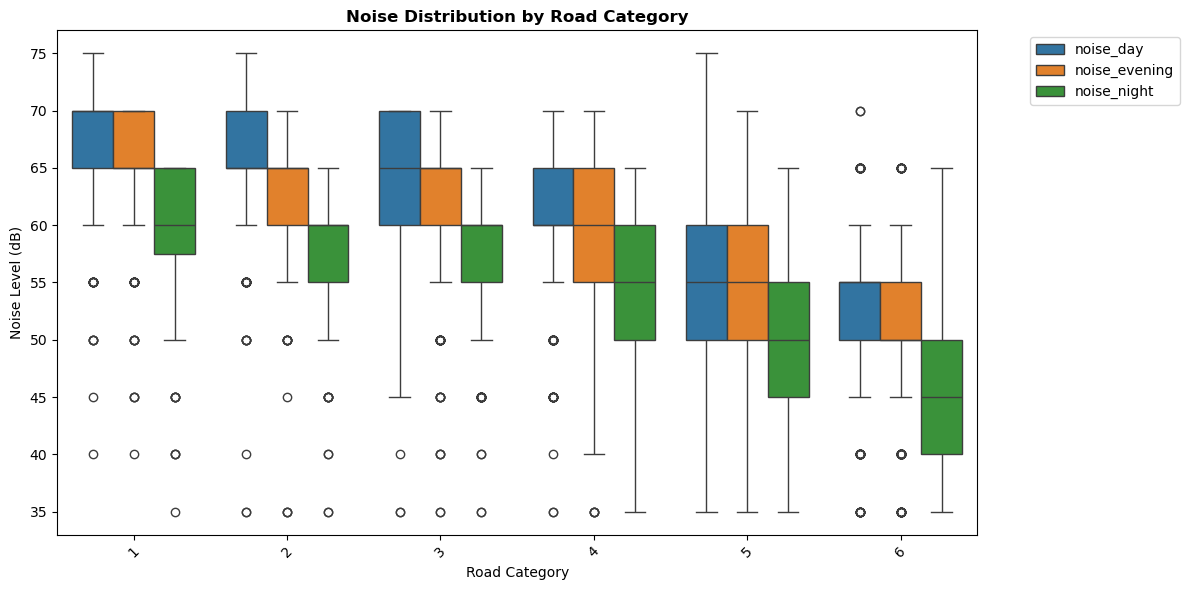

In [55]:
#Replace 0 values in noise_day with 35 otherwisse 0 result as an outlier
dataset_small['noise_day'] = dataset_small['noise_day'].replace(0, 35)
print(dataset_small['noise_day'].unique())
dataset_small['noise_evening'] = dataset_small['noise_evening'].replace(0, 35)
print(dataset_small['noise_evening'].unique())
dataset_small['noise_night'] = dataset_small['noise_night'].replace(0, 35)
print(dataset_small['noise_night'].unique())

# Prepare data: melt to long format for easier plotting
dataset_melted = dataset_small.melt(
    id_vars=['road_category'],
    value_vars=['noise_day', 'noise_evening', 'noise_night'],
    var_name='noise_type',
    value_name='noise_level'
)

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Box plot
sns.boxplot(
    data=dataset_melted,
    x='road_category',
    y='noise_level',
    hue='noise_type',
    ax=ax
)
ax.set_title('Noise Distribution by Road Category', fontsize=12, fontweight='bold')
ax.set_xlabel('Road Category')
ax.set_ylabel('Noise Level (dB)')
ax.tick_params(axis='x', rotation=45)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Noise Distribution by Road Width

[55 50 45 60 65 70 40 35 75]
[55 50 45 60 65 70 40 35]
[50 45 40 55 60 65 35]
[15.40432042  9.38271516 36.72221219 ... 40.93775698  1.75537319
 12.47074027]
0.0 50.0


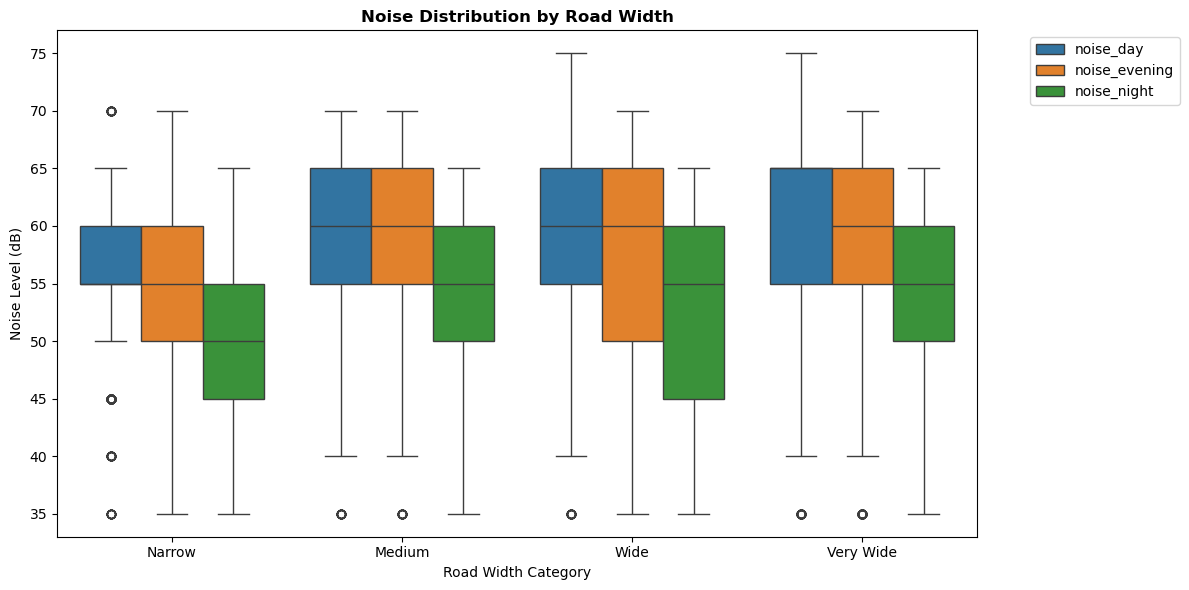

Road width statistics:
count    8386.000000
mean       24.432135
std        13.760877
min         0.000000
25%        11.924782
50%        22.703079
75%        34.368280
max        50.000000
Name: road_width, dtype: float64

Noise statistics by road width category:
                                    count       mean       std   min   25%  \
road_width_category variable                                                 
Narrow              noise_day      2234.0  56.434646  5.744093  35.0  55.0   
                    noise_evening  2234.0  54.764996  5.762567  35.0  50.0   
                    noise_night    2234.0  49.829902  6.059319  35.0  45.0   
Medium              noise_day      2492.0  59.183387  7.092699  35.0  55.0   
                    noise_evening  2492.0  57.512039  7.027635  35.0  55.0   
                    noise_night    2492.0  52.552167  7.003131  35.0  50.0   
Wide                noise_day      1990.0  58.917085  7.621690  35.0  55.0   
                    noise_evenin

In [56]:
#Replace 0 values in noise_day with 35 otherwisse 0 result as an outlier
dataset_small['noise_day'] = dataset_small['noise_day'].replace(0, 35)
print(dataset_small['noise_day'].unique())
dataset_small['noise_evening'] = dataset_small['noise_evening'].replace(0, 35)
print(dataset_small['noise_evening'].unique())
dataset_small['noise_night'] = dataset_small['noise_night'].replace(0, 35)
print(dataset_small['noise_night'].unique())

print(dataset_small['road_width'].unique())
print(dataset_small['road_width'].min(), dataset_small['road_width'].max())

# Bin road_width into categories
dataset_small['road_width_category'] = pd.cut(dataset_small['road_width'], bins=4, labels=['Narrow', 'Medium', 'Wide', 'Very Wide'])

# Prepare data for road width plot
dataset_melted_width = dataset_small.melt(
    id_vars=['road_width_category'],
    value_vars=['noise_day', 'noise_evening', 'noise_night'],
    value_name='noise_level'
)

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Box plot
sns.boxplot(
    data=dataset_melted_width,
    x='road_width_category',
    y='noise_level',
    hue='variable',
    ax=ax
)
ax.set_title('Noise Distribution by Road Width', fontsize=12, fontweight='bold')
ax.set_xlabel('Road Width Category')
ax.set_ylabel('Noise Level (dB)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

print(f"Road width statistics:")
print(dataset_small['road_width'].describe())
print(f"\nNoise statistics by road width category:")
print(dataset_melted_width.groupby(['road_width_category', 'variable'])['noise_level'].describe())

## Relationship between Road Category and Road Width

C:\Users\cutro\AppData\Local\Temp\ipykernel_12964\3690045003.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


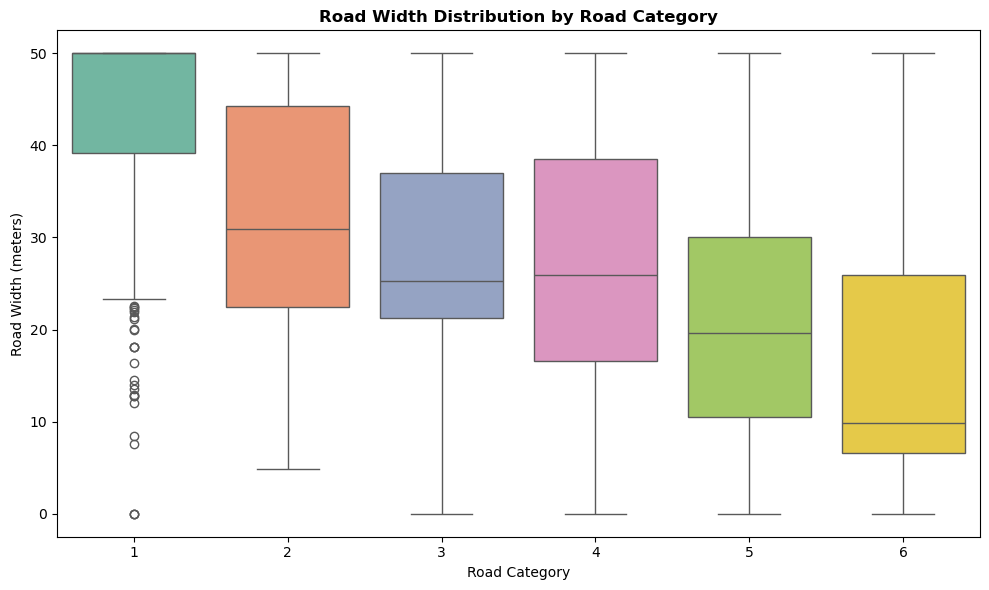


Correlation between Road Category and Road Width:
Spearman correlation: -0.3703


In [60]:
# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Box plot of road width by road category
sns.boxplot(
    data=dataset_small,
    x='road_category',
    y='road_width',
    ax=ax,
    palette='Set2'
)
ax.set_title('Road Width Distribution by Road Category', fontsize=12, fontweight='bold')
ax.set_xlabel('Road Category')
ax.set_ylabel('Road Width (meters)')

plt.tight_layout()
plt.show()

# Statistics
print("\nCorrelation between Road Category and Road Width:")
print(f"Spearman correlation: {dataset_small['road_category'].corr(dataset_small['road_width'], method='spearman'):.4f}")

## Noise Distribution by Traffic Count Metrics

Daytime count per meter stats:
count    8386.000000
mean        0.116346
std         0.248118
min         0.000000
25%         0.009874
50%         0.037885
75%         0.121062
max         4.438147
Name: daytime_count_per_meter_100m, dtype: float64
Nighttime count per meter stats:
count    8386.000000
mean        0.027749
std         0.071293
min         0.000000
25%         0.000000
50%         0.000000
75%         0.026058
max         1.566405
Name: nighttime_count_per_meter_100m, dtype: float64


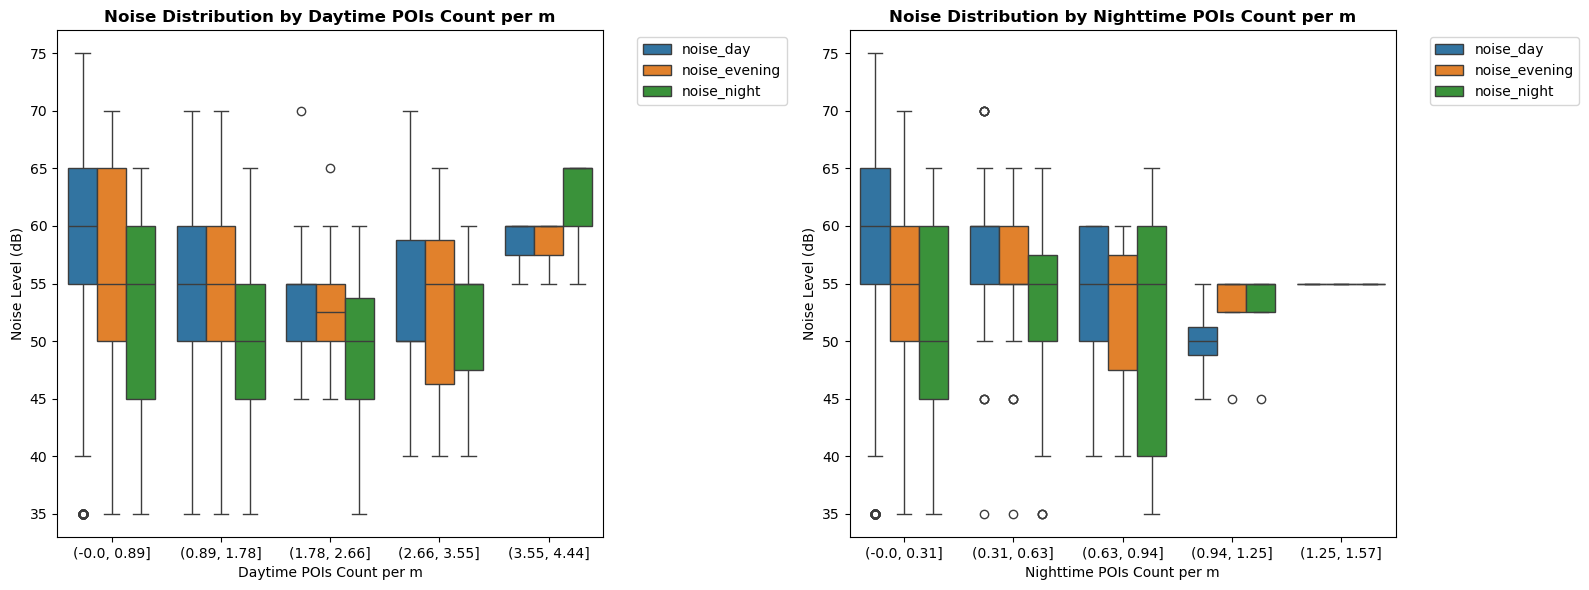

In [71]:
# Add traffic count columns from original dataset
dataset_small['daytime_count_per_meter_100m'] = dataset['daytime_count_per_meter_100m']
dataset_small['nighttime_count_per_meter_100m'] = dataset['nighttime_count_per_meter_100m']

# Check the data
print("Daytime count per meter stats:")
print(dataset_small['daytime_count_per_meter_100m'].describe())
print("Nighttime count per meter stats:")
print(dataset_small['nighttime_count_per_meter_100m'].describe())

# Bin traffic counts into categories with rounded ranges
daytime_bins = pd.cut(dataset_small['daytime_count_per_meter_100m'], bins=5)
nighttime_bins = pd.cut(dataset_small['nighttime_count_per_meter_100m'], bins=5)

# Round the interval labels to 2 decimal places
dataset_small['daytime_traffic_category'] = daytime_bins.apply(lambda x: pd.Interval(round(x.left, 2), round(x.right, 2), closed=x.closed) if pd.notna(x) else None)
dataset_small['nighttime_traffic_category'] = nighttime_bins.apply(lambda x: pd.Interval(round(x.left, 2), round(x.right, 2), closed=x.closed) if pd.notna(x) else None)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Daytime traffic box plot
dataset_melted_daytime = dataset_small.melt(
    id_vars=['daytime_traffic_category'],
    value_vars=['noise_day', 'noise_evening', 'noise_night'],
    value_name='noise_level'
)

sns.boxplot(
    data=dataset_melted_daytime,
    x='daytime_traffic_category',
    y='noise_level',
    hue='variable',
    ax=axes[0]
)
axes[0].set_title('Noise Distribution by Daytime POIs Count per m', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Daytime POIs Count per m')
axes[0].set_ylabel('Noise Level (dB)')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Nighttime traffic box plot
dataset_melted_nighttime = dataset_small.melt(
    id_vars=['nighttime_traffic_category'],
    value_vars=['noise_day', 'noise_evening', 'noise_night'],
    value_name='noise_level'
)

sns.boxplot(
    data=dataset_melted_nighttime,
    x='nighttime_traffic_category',
    y='noise_level',
    hue='variable',
    ax=axes[1]
)
axes[1].set_title('Noise Distribution by Nighttime POIs Count per m', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Nighttime POIs Count per m')
axes[1].set_ylabel('Noise Level (dB)')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Continuous count per meter stats:
count    8386.000000
mean        0.244567
std         0.607384
min         0.000000
25%         0.031965
50%         0.089081
75%         0.227380
max         8.300912
Name: continuous_count_per_meter_100m, dtype: float64
Discontinuous count per meter stats:
count    8386.000000
mean        0.122870
std         0.291246
min         0.000000
25%         0.000000
50%         0.030136
75%         0.118958
max         5.743485
Name: discontinuous_count_per_meter_100m, dtype: float64


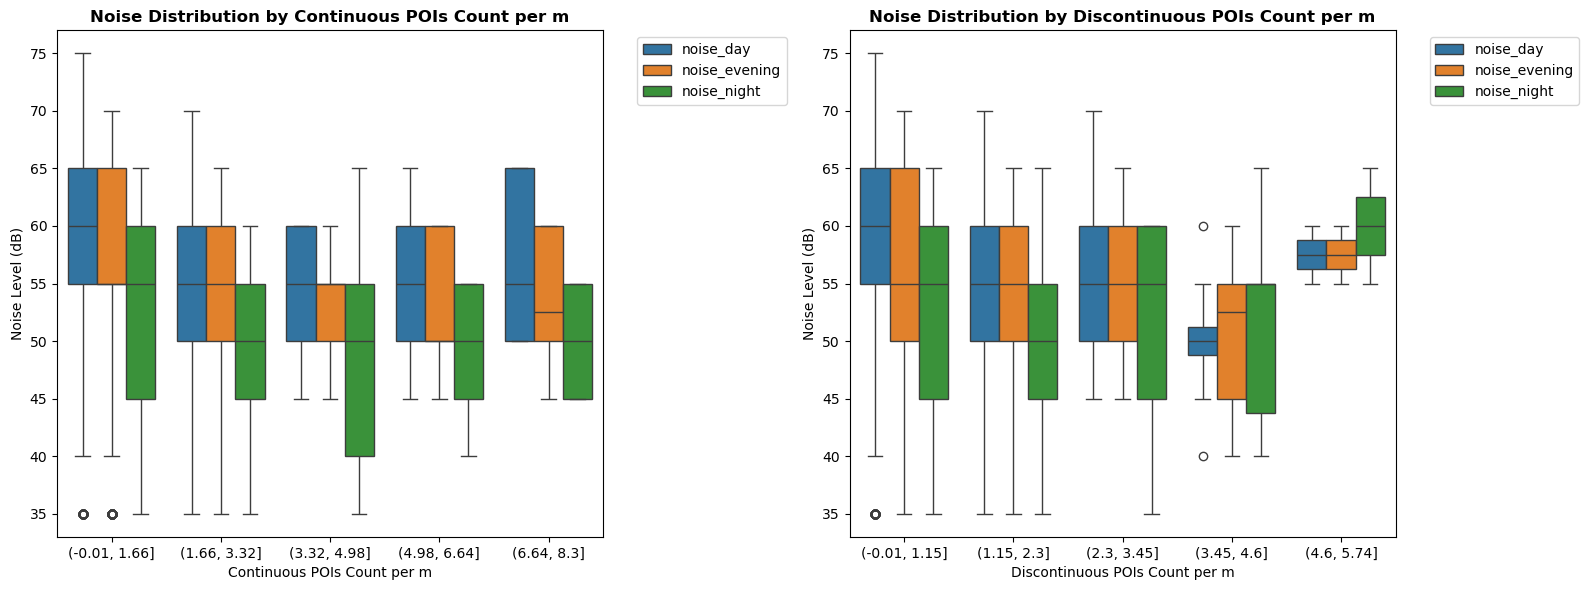

In [74]:
# Add continuous and discontinuous traffic count columns from original dataset
dataset_small['continuous_count_per_meter_100m'] = dataset['continuous_count_per_meter_100m']
dataset_small['discontinuous_count_per_meter_100m'] = dataset['discontinuous_count_per_meter_100m']

# Check the data
print("Continuous count per meter stats:")
print(dataset_small['continuous_count_per_meter_100m'].describe())
print("Discontinuous count per meter stats:")
print(dataset_small['discontinuous_count_per_meter_100m'].describe())

# Bin traffic counts into categories with rounded ranges
continuous_bins = pd.cut(dataset_small['continuous_count_per_meter_100m'], bins=5)
discontinuous_bins = pd.cut(dataset_small['discontinuous_count_per_meter_100m'], bins=5)

# Round the interval labels to 2 decimal places
dataset_small['continuous_traffic_category'] = continuous_bins.apply(lambda x: pd.Interval(round(x.left, 2), round(x.right, 2), closed=x.closed) if pd.notna(x) else None)
dataset_small['discontinuous_traffic_category'] = discontinuous_bins.apply(lambda x: pd.Interval(round(x.left, 2), round(x.right, 2), closed=x.closed) if pd.notna(x) else None)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Continuous traffic box plot
dataset_melted_continuous = dataset_small.melt(
    id_vars=['continuous_traffic_category'],
    value_vars=['noise_day', 'noise_evening', 'noise_night'],
    value_name='noise_level'
)

sns.boxplot(
    data=dataset_melted_continuous,
    x='continuous_traffic_category',
    y='noise_level',
    hue='variable',
    ax=axes[0]
)
axes[0].set_title('Noise Distribution by Continuous POIs Count per m', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Continuous POIs Count per m')
axes[0].set_ylabel('Noise Level (dB)')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Discontinuous traffic box plot
dataset_melted_discontinuous = dataset_small.melt(
    id_vars=['discontinuous_traffic_category'],
    value_vars=['noise_day', 'noise_evening', 'noise_night'],
    value_name='noise_level'
)

sns.boxplot(
    data=dataset_melted_discontinuous,
    x='discontinuous_traffic_category',
    y='noise_level',
    hue='variable',
    ax=axes[1]
)
axes[1].set_title('Noise Distribution by Discontinuous POIs Count per m', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Discontinuous POIs Count per m')
axes[1].set_ylabel('Noise Level (dB)')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Noise Distribution by Betweenness Centrality

Edge betweenness stats:
count    8386.000000
mean        0.003894
std         0.006512
min         0.000000
25%         0.000110
50%         0.000997
75%         0.004563
max         0.064422
Name: edge_betweenness, dtype: float64


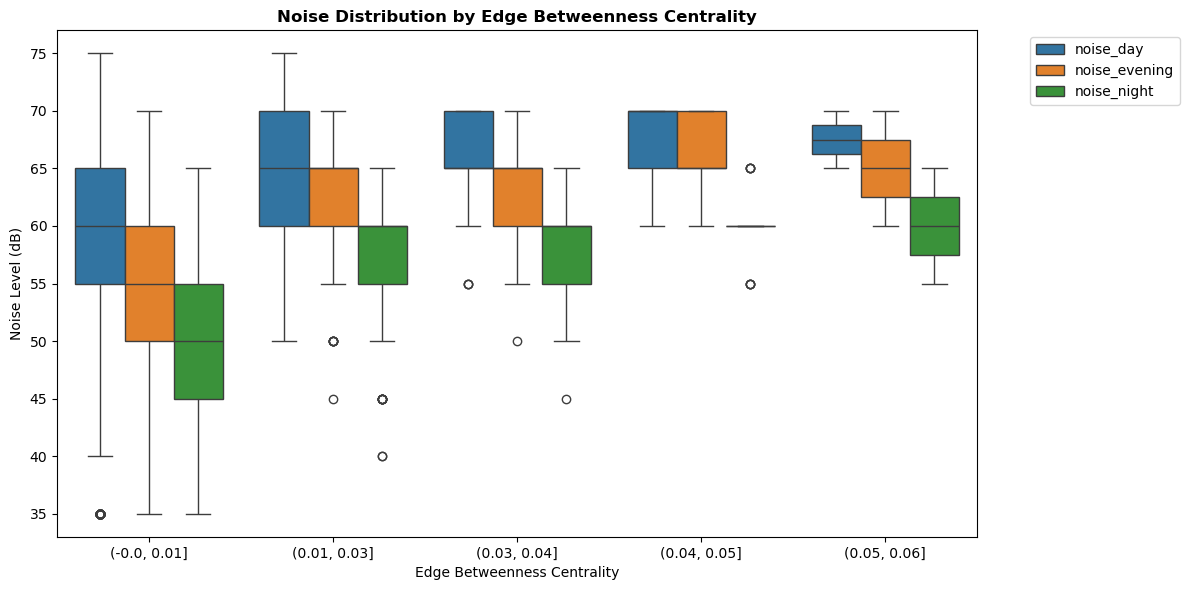


Noise statistics by betweenness category:
                                     count       mean       std   min    25%  \
betweenness_category variable                                                  
(-0.0, 0.01]         noise_day      7588.0  58.016605  7.360136  35.0  55.00   
                     noise_evening  7588.0  56.310622  7.296656  35.0  50.00   
                     noise_night    7588.0  51.438455  7.220694  35.0  45.00   
(0.01, 0.03]         noise_day       646.0  65.030960  4.295189  50.0  60.00   
                     noise_evening   646.0  63.250774  4.335427  45.0  60.00   
                     noise_night     646.0  58.126935  4.443197  40.0  55.00   
(0.03, 0.04]         noise_day       132.0  65.454545  3.780956  55.0  65.00   
                     noise_evening   132.0  63.977273  3.845223  50.0  60.00   
                     noise_night     132.0  59.128788  3.783058  45.0  55.00   
(0.04, 0.05]         noise_day        18.0  67.777778  3.078494  60.0  65.00 

In [ ]:
# Check the edge_betweenness data
print("Edge betweenness stats:")
print(dataset_small['edge_betweenness'].describe())

# Bin edge_betweenness into categories with rounded ranges
betweenness_bins = pd.cut(dataset_small['edge_betweenness'], bins=5)

# Round the interval labels to 2 decimal places
dataset_small['betweenness_category'] = betweenness_bins.apply(lambda x: pd.Interval(round(x.left, 2), round(x.right, 2), closed=x.closed) if pd.notna(x) else None)

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for betweenness plot
dataset_melted_betweenness = dataset_small.melt(
    id_vars=['betweenness_category'],
    value_vars=['noise_day', 'noise_evening', 'noise_night'],
    value_name='noise_level'
)

# Box plot
sns.boxplot(
    data=dataset_melted_betweenness,
    x='betweenness_category',
    y='noise_level',
    hue='variable',
    ax=ax
)
ax.set_title('Noise Distribution by Edge Betweenness Centrality', fontsize=12, fontweight='bold')
ax.set_xlabel('Edge Betweenness Centrality')
ax.set_ylabel('Noise Level (dB)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Noise Distribution by Traffic Signal Count

Signal count (50m buffer) stats:
count    8386.000000
mean        2.616504
std         3.000868
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max        40.000000
Name: signal_count_50, dtype: float64


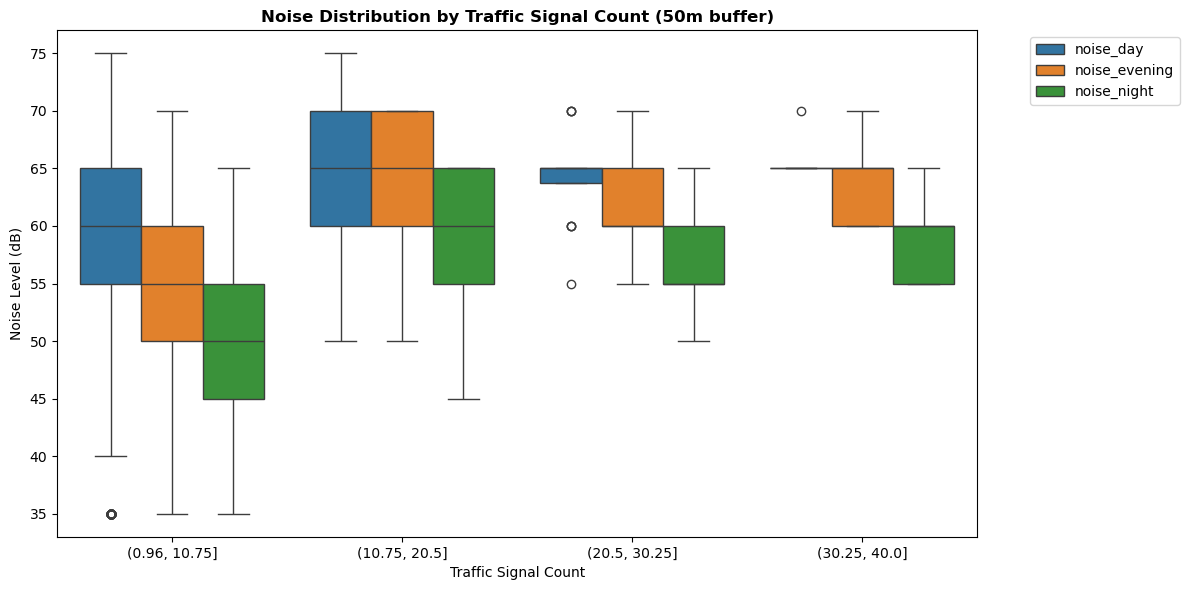


Noise statistics by signal count category:
                                      count       mean       std   min    25%  \
signal_count_category variable                                                  
(0.96, 10.75]         noise_day      8156.0  58.507234  7.403585  35.0  55.00   
                      noise_evening  8156.0  56.794998  7.338043  35.0  50.00   
                      noise_night    8156.0  51.902894  7.255241  35.0  45.00   
(10.75, 20.5]         noise_day       209.0  65.502392  4.397469  50.0  60.00   
                      noise_evening   209.0  63.947368  4.582797  50.0  60.00   
                      noise_night     209.0  59.043062  4.524831  45.0  55.00   
(20.5, 30.25]         noise_day        16.0  64.375000  4.031129  55.0  63.75   
                      noise_evening    16.0  62.187500  4.819665  55.0  60.00   
                      noise_night      16.0  57.187500  4.819665  50.0  55.00   
(30.25, 40.0]         noise_day         5.0  66.000000  2.236068 

In [77]:
# Check the signal_count_50 data
print("Signal count (50m buffer) stats:")
print(dataset_small['signal_count_50'].describe())

# Bin signal_count into categories with rounded ranges
signal_bins = pd.cut(dataset_small['signal_count_50'], bins=4)

# Round the interval labels to 2 decimal places
dataset_small['signal_count_category'] = signal_bins.apply(lambda x: pd.Interval(round(x.left, 2), round(x.right, 2), closed=x.closed) if pd.notna(x) else None)

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for signal count plot
dataset_melted_signal = dataset_small.melt(
    id_vars=['signal_count_category'],
    value_vars=['noise_day', 'noise_evening', 'noise_night'],
    value_name='noise_level'
)

# Box plot
sns.boxplot(
    data=dataset_melted_signal,
    x='signal_count_category',
    y='noise_level',
    hue='variable',
    ax=ax
)
ax.set_title('Noise Distribution by Traffic Signal Count (50m buffer)', fontsize=12, fontweight='bold')
ax.set_xlabel('Traffic Signal Count')
ax.set_ylabel('Noise Level (dB)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

print(f"\nNoise statistics by signal count category:")
print(dataset_melted_signal.groupby(['signal_count_category', 'variable'])['noise_level'].describe())

## Parallel Coordinates

In [56]:
# Select numeric columns
dataset_num = dataset_small.drop(columns=['noise_day', 'noise_evening', 'noise_night']) #dropping y and non-numeric columns
numeric_cols = dataset_num.columns.tolist()
print(f"Numeric columns: {numeric_cols}")


Numeric columns: ['road_category', 'road_width', 'openness', 'road_length', 'osm_commercial_pct_50m', 'osm_green_pct_50m', 'osm_industrial_pct_50m', 'osm_other_pct_50m', 'osm_residential_pct_50m', 'slope_pct', 'catastral_bldg_floors_mean_50m', 'signal_count_50', 'poi_count_50', 'tree_count_50', 'transport_count_50', 'edge_betweenness']


### Day Noise

In [57]:
# Create parallel coordinates plot for day noise
fig_day = px.parallel_coordinates(
    dataset,
    dimensions=[col for col in numeric_cols],
    color='noise_day' if 'noise_day' in numeric_cols else numeric_cols[-1],
    color_continuous_scale='Viridis',
    labels={col: col.replace('_', ' ').title() for col in numeric_cols},
    title='Parallel Coordinates Plot - Actual Feature Values Colored by Day Noise',
    height=700,
    width=1400
)

fig_day.update_layout(
    font=dict(size=10),
    coloraxis_colorbar=dict(title="Day Noise Level")
)

fig_day.show()

### Evening Noise

In [58]:
# Create parallel coordinates plot for evening noise
fig_evening = px.parallel_coordinates(
    dataset,
    dimensions=[col for col in numeric_cols],
    color='noise_evening' if 'noise_evening' in numeric_cols else numeric_cols[-1],
    color_continuous_scale='RdYlGn_r',
    labels={col: col.replace('_', ' ').title() for col in numeric_cols},
    title='Parallel Coordinates Plot - Actual Feature Values Colored by Evening Noise',
    height=700,
    width=1400
)

fig_evening.update_layout(
    font=dict(size=10),
    coloraxis_colorbar=dict(title="Evening Noise Level")
)

fig_evening.show()

### Night Noise

In [59]:
# Create parallel coordinates plot for night noise
fig_night = px.parallel_coordinates(
    dataset,
    dimensions=[col for col in numeric_cols],
    color='noise_night' if 'noise_night' in numeric_cols else numeric_cols[-1],
    color_continuous_scale='Blues',
    labels={col: col.replace('_', ' ').title() for col in numeric_cols},
    title='Parallel Coordinates Plot - Actual Feature Values Colored by Night Noise',
    height=700,
    width=1400
)

fig_night.update_layout(
    font=dict(size=10),
    coloraxis_colorbar=dict(title="Night Noise Level")
)

fig_night.show()